In [1]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
import numpy as np
import copy
from collections import defaultdict, deque
import pickle
import random
from tqdm import trange
import matplotlib.pyplot as plt

In [2]:
# Operator type
Operator = Optional[str]

@dataclass
class Piece:
    player: int  # 1 = Blue, -1 = Red
    value: int
    dama: bool = False

    def __repr__(self):
        p = "🔵" if self.player == 1 else "🔴"
        val = f"{self.value:+d}" if self.value >= 0 else str(self.value)
        return f"{p}{'D' if self.dama else ''}{val}"
    
    def copy(self):
        return Piece(self.player, self.value, self.dama)
    
@dataclass
class Move:
    path: List[Tuple[int, int]]
    captures: List[Tuple[int, int]]
    promotes: bool = False
    score_gain: int = 0
    is_dama_capture: bool = False
    is_multi_jump: bool = False

    def __repr__(self):
        cap_str = f" x{len(self.captures)}" if self.captures else ""
        promo = " (promo)" if self.promotes else ""
        return f"{self.path}{cap_str}{promo} +{self.score_gain}"


In [3]:
class DamathEnv:
    def __init__(self, rows=8, cols=8, operator_pattern=None):
        self.R = rows
        self.C = cols
        if operator_pattern is None:
            operator_pattern = self.default_operator_board()
        self.op_board = operator_pattern
        self.pieces: Dict[Tuple[int,int], Piece] = {}
        self.scores = {1: 0.0, -1: 0.0}
        self.to_move = 1
        self.history_states = deque(maxlen=50)
        self.init_default_integer_setup()

    def default_operator_board(self):
        ops = ['x','/','-','+']
        board = [[None for _ in range(self.C)] for __ in range(self.R)]
        for r in range(self.R):
            for c in range(self.C):
                if (r + c) % 2 == 1:
                    board[r][c] = ops[(r + 2*c) % len(ops)]
        return board

    def init_default_integer_setup(self):
        self.pieces = {}
        blue_values = [[-11, 8, -5, 2], [0, -3, 10, -7], [-9, 6, -1, 4]]
        red_values = [[4, -1, 6, -9], [-7, 10, -3, 0], [2, -5, 8, -11]]
        
        def playable_positions_on_row(r):
            return [c for c in range(self.C) if (r+c)%2==1]
        
        for i, r in enumerate(range(0,3)):
            cols = playable_positions_on_row(r)
            vals = blue_values[i]
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r,c)] = Piece(player=1, value=vals[j], dama=False)
        
        for i, r in enumerate(range(5,8)):
            cols = playable_positions_on_row(r)
            vals = red_values[i]
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r,c)] = Piece(player=-1, value=vals[j], dama=False)
        
        self.scores = {1:0.0, -1:0.0}
        self.to_move = 1
        self.history_states.clear()
        self.record_state()

    def copy(self):
        newenv = DamathEnv(self.R, self.C)
        newenv.op_board = copy.deepcopy(self.op_board)
        newenv.pieces = {k: v.copy() for k,v in self.pieces.items()}
        newenv.scores = dict(self.scores)
        newenv.to_move = self.to_move
        newenv.history_states = copy.deepcopy(self.history_states)
        return newenv

    def in_bounds(self, r, c):
        return 0 <= r < self.R and 0 <= c < self.C

    def is_playable(self, r, c):
        return self.in_bounds(r,c) and ((r+c)%2==1)

    def record_state(self):
        items = tuple(sorted([(pos, p.player, p.value, p.dama) for pos, p in self.pieces.items()]))
        key = (self.to_move, items)
        self.history_states.append(key)

    def op_at(self, r, c):
        return self.op_board[r][c] if self.is_playable(r,c) else None

    def apply_operator(self, op: str, a: int, b: int):
        if op == '+': return a + b
        if op == '-': return a - b
        if op in ['x', 'X', '*']: return a * b
        if op == '/': return int(a / b) if b != 0 else 0
        raise ValueError(f"Unknown op {op}")

    def generate_all_moves(self, player: int):
        capture_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player: continue
            caps = self._generate_captures_from(pos, piece)
            capture_moves.extend(caps)
        
        if capture_moves:
            max_cap = max(len(m.captures) for m in capture_moves)
            maxcap_moves = [m for m in capture_moves if len(m.captures)==max_cap]
            if any(self.pieces[m.path[0]].dama for m in maxcap_moves):
                maxcap_moves = [m for m in maxcap_moves if self.pieces[m.path[0]].dama]
            for m in maxcap_moves:
                m.score_gain = self._compute_move_score(m, player)
            return maxcap_moves
        
        simple_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player: continue
            sms = self._generate_simple_from(pos, piece)
            simple_moves.extend(sms)
        for m in simple_moves:
            m.score_gain = 0.0
        return simple_moves

    def _generate_simple_from(self, pos, piece: Piece):
        r, c = pos
        moves = []
        if piece.dama:
            for dr, dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                step = 1
                while True:
                    nr, nc = r + dr*step, c + dc*step
                    if not self.in_bounds(nr,nc) or not self.is_playable(nr,nc): break
                    if (nr,nc) in self.pieces: break
                    path = [(r,c),(nr,nc)]
                    promotes = self._check_promotion(nr, piece.player)
                    moves.append(Move(path=path, captures=[], promotes=promotes))
                    step += 1
        else:
            dr = 1 if piece.player==1 else -1
            for dc in (-1,1):
                nr, nc = r + dr, c + dc
                if not self.in_bounds(nr,nc) or not self.is_playable(nr,nc): continue
                if (nr,nc) in self.pieces: continue
                path = [(r,c),(nr,nc)]
                promotes = self._check_promotion(nr, piece.player)
                moves.append(Move(path=path, captures=[], promotes=promotes))
        return moves

    def _generate_captures_from(self, pos, piece: Piece):
        results = []
        r, c = pos
        
        if not piece.dama:
            for dr, dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                ar, ac = r + dr, c + dc
                lr, lc = r + 2*dr, c + 2*dc
                if not self.in_bounds(ar,ac) or not self.is_playable(ar,ac): continue
                if (ar,ac) not in self.pieces: continue
                if self.pieces[(ar,ac)].player == piece.player: continue
                if not self.in_bounds(lr,lc) or not self.is_playable(lr,lc): continue
                if (lr,lc) in self.pieces: continue
                
                new_env = self.copy()
                captured_piece = new_env.pieces.pop((ar,ac))
                moved_piece = new_env.pieces.pop((r,c))
                new_env.pieces[(lr,lc)] = moved_piece
                further = new_env._generate_captures_from((lr,lc), moved_piece)
                
                if not further:
                    m = Move(path=[(r,c),(lr,lc)], captures=[(ar,ac,captured_piece)], 
                            promotes=self._check_promotion(lr,piece.player))
                    results.append(m)
                else:
                    for fm in further:
                        m = Move(path=[(r,c)] + fm.path, 
                                captures=[(ar,ac,captured_piece)] + fm.captures,
                                promotes=self._check_promotion(fm.path[-1][0], piece.player))
                        results.append(m)
        
        return results

    def _compute_move_score(self, move: Move, mover_player: int):
        total = 0.0
        mover_start = move.path[0]
        mover_piece = self.pieces.get(mover_start)
        mover_is_dama = mover_piece.dama if mover_piece else False
        mover_value = mover_piece.value if mover_piece else 0
        
        for i, (cap_r, cap_c, cap_piece) in enumerate(move.captures):
            landing = move.path[1+i] if len(move.path) > 1+i else move.path[-1]
            op = self.op_at(*landing)
            base = self.apply_operator(op, mover_value, cap_piece.value)
            
            mult = 1
            if mover_is_dama and cap_piece.dama:
                mult = 4
            elif mover_is_dama or cap_piece.dama:
                mult = 2
            total += base * mult
        return total

    def _check_promotion(self, r, player):
        if player==1 and r==self.R-1: return True
        if player==-1 and r==0: return True
        return False

    def apply_move(self, move: Move):
        player = self.to_move
        total_gain = 0.0
        
        if not move.captures:
            frm, to = move.path[0], move.path[-1]
            piece = self.pieces.pop(frm)
            self.pieces[to] = piece
            if self._check_promotion(to[0], piece.player) and not piece.dama:
                piece.dama = True
        else:
            frm = move.path[0]
            mover = self.pieces.pop(frm)
            current_pos = frm
            
            for i, (cap_r, cap_c, cap_piece_snapshot) in enumerate(move.captures):
                landing = move.path[1 + i] if 1 + i < len(move.path) else move.path[-1]
                op = self.op_at(*landing)
                self.pieces.pop((cap_r, cap_c))
                
                base = self.apply_operator(op, mover.value, cap_piece_snapshot.value)
                mult = 1
                if mover.dama and cap_piece_snapshot.dama:
                    mult = 4
                elif mover.dama or cap_piece_snapshot.dama:
                    mult = 2
                
                gain = base * mult
                total_gain += gain
                current_pos = landing
            
            self.pieces[current_pos] = mover
            if self._check_promotion(current_pos[0], mover.player) and not mover.dama:
                mover.dama = True
            
            self.scores[mover.player] += total_gain
        
        self.to_move *= -1
        self.record_state()
        return total_gain

    def game_over(self):
        if not self.generate_all_moves(self.to_move):
            return True
        players_present = set(p.player for p in self.pieces.values())
        if len(players_present) <= 1:
            return True
        return False

    def final_scores_and_winner(self):
        final_scores = dict(self.scores)
        for pos, piece in self.pieces.items():
            val = piece.value * (2 if piece.dama else 1)
            final_scores[piece.player] += val
        
        if final_scores[1] > final_scores[-1]:
            winner = 1
        elif final_scores[1] < final_scores[-1]:
            winner = -1
        else:
            winner = 0
        return final_scores, winner

    def get_state_hash(self):
        items = tuple(sorted([(pos, p.player, p.value, p.dama) 
                             for pos, p in self.pieces.items()]))
        return (self.to_move, items)
    
    def compute_final_reward_for(self, player: int = 1, reward_alpha: float = 0.7, K: float = 100.0):
        """
        Compute final combined reward for `player`.
        final_reward = [reward_alpha * binary_outcome + (1 - reward_alpha) * tanh((score_diff)/K)]
        Returns (final_reward, winner, final_scores)
        """
        final_scores, winner = self.final_scores_and_winner()
        p_score = final_scores.get(player, 0.0)
        o_score = final_scores.get(-player, 0.0)
        
        # Binary component
        if winner == player:
            binary_reward = 1.0
        elif winner == -player:
            binary_reward = -1.0
        else:
            binary_reward = 0.0
        
        # Normalized score difference
        norm_diff = float(np.tanh((p_score - o_score) / K))
        final_reward = float(reward_alpha * binary_reward + (1 - reward_alpha) * norm_diff)
        final_reward = float(np.clip(final_reward, -1.0, 1.0))
        
        return final_reward, winner, final_scores


In [4]:
class QLearner:
    def __init__(self, learning_rate=0.01, gamma=0.9, epsilon=0.2):
        self.Q = defaultdict(lambda: defaultdict(float))
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
 

    def get_q(self, state, action):
        return self.Q[state][action]

    def choose_action(self, env, moves):
        if not moves:
            return None
        
        if random.random() < self.epsilon:
            return random.choice(moves)
        
        state = env.get_state_hash()
        q_values = [(self.get_q(state, self._move_to_key(m)), m) for m in moves]
        max_q = max(q_values, key=lambda x: x[0])[0]
        best_moves = [m for q, m in q_values if q == max_q]
        return random.choice(best_moves)

    def update(self, state, action, reward, next_state, next_moves, done):
        state_key = state
        action_key = self._move_to_key(action)
        
        current_q = self.get_q(state_key, action_key)
        
        if done or not next_moves:
            target = reward
        else:
            next_state_key = next_state
            max_next_q = max([self.get_q(next_state_key, self._move_to_key(m)) 
                             for m in next_moves], default=0.0)
            target = reward + self.gamma * max_next_q
        
        self.Q[state_key][action_key] = current_q + self.learning_rate * (target - current_q)

    def _move_to_key(self, move):
        return (tuple(move.path), tuple((r, c) for r, c, _ in move.captures))

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump(dict(self.Q), f)

    def load(self, path):
        with open(path, 'rb') as f:
            self.Q = defaultdict(lambda: defaultdict(float), pickle.load(f))


In [5]:
class MetricsTracker:
    """Track comprehensive metrics for Q-learning game episodes"""
    
    def __init__(self):
        self.reset()
    
    def reset(self):
        """Reset all metrics"""
        self.episodes = []
        self.p1_wins = 0
        self.p2_wins = 0
        self.draws = 0
        self.score_diffs = []
        self.episode_lengths = []
        self.rewards_p1 = []
        self.rewards_p2 = []
        self.final_scores_p1 = []
        self.final_scores_p2 = []
    
    def record_episode(self, winner: int, final_scores: Dict, episode_length: int, 
                      final_reward_p1: float, final_reward_p2: float):
        """Record metrics for a completed episode"""
        # Track wins
        if winner == 1:
            self.p1_wins += 1
        elif winner == -1:
            self.p2_wins += 1
        else:
            self.draws += 1
        
        # Track scores
        p1_score = final_scores.get(1, 0.0)
        p2_score = final_scores.get(-1, 0.0)
        self.final_scores_p1.append(p1_score)
        self.final_scores_p2.append(p2_score)
        
        # Track score differential (absolute value)
        score_diff = abs(p1_score - p2_score)
        self.score_diffs.append(score_diff)
        
        # Track episode length
        self.episode_lengths.append(episode_length)
        
        # Track rewards
        self.rewards_p1.append(final_reward_p1)
        self.rewards_p2.append(final_reward_p2)
        
        # Store episode data
        self.episodes.append({
            'episode': len(self.episodes) + 1,
            'winner': winner,
            'p1_score': p1_score,
            'p2_score': p2_score,
            'score_diff': score_diff,
            'length': episode_length,
            'reward_p1': final_reward_p1,
            'reward_p2': final_reward_p2
        })
    
    def get_summary(self) -> Dict:
        """Get comprehensive summary of all metrics"""
        total_games = self.p1_wins + self.p2_wins + self.draws
        
        return {
            'total_episodes': len(self.episodes),
            'p1_cumulative_wins': self.p1_wins,
            'p2_cumulative_wins': self.p2_wins,
            'draws': self.draws,
            'p1_winrate': (self.p1_wins / total_games * 100) if total_games > 0 else 0.0,
            'p2_winrate': (self.p2_wins / total_games * 100) if total_games > 0 else 0.0,
            'avg_score_diff': np.mean(self.score_diffs) if self.score_diffs else 0.0,
            'avg_episode_length': np.mean(self.episode_lengths) if self.episode_lengths else 0.0,
            'p1_mean_abs_reward': np.mean(np.abs(self.rewards_p1)) if self.rewards_p1 else 0.0,
            'p2_mean_abs_reward': np.mean(np.abs(self.rewards_p2)) if self.rewards_p2 else 0.0,
            'p1_avg_score': np.mean(self.final_scores_p1) if self.final_scores_p1 else 0.0,
            'p2_avg_score': np.mean(self.final_scores_p2) if self.final_scores_p2 else 0.0
        }
    
    def print_summary(self):
        """Print formatted summary of metrics"""
        summary = self.get_summary()
        print("="*60)
        print("TRAINING METRICS SUMMARY")
        print("="*60)
        print(f"Total Episodes: {summary['total_episodes']}")
        print(f"\nCumulative Wins:")
        print(f"  Player 1 (Blue): {summary['p1_cumulative_wins']} ({summary['p1_winrate']:.2f}%)")
        print(f"  Player 2 (Red):  {summary['p2_cumulative_wins']} ({summary['p2_winrate']:.2f}%)")
        print(f"  Draws: {summary['draws']}")
        print(f"\nScore Metrics:")
        print(f"  Avg Score Differential (Absolute): {summary['avg_score_diff']:.2f}")
        print(f"  P1 Avg Final Score: {summary['p1_avg_score']:.2f}")
        print(f"  P2 Avg Final Score: {summary['p2_avg_score']:.2f}")
        print(f"\nEpisode Metrics:")
        print(f"  Avg Episode Length: {summary['avg_episode_length']:.2f} moves")
        print(f"\nReward Metrics:")
        print(f"  P1 Mean Absolute Reward: {summary['p1_mean_abs_reward']:.4f}")
        print(f"  P2 Mean Absolute Reward: {summary['p2_mean_abs_reward']:.4f}")
        print("="*60)
    
    def plot_metrics(self, window: int = 100):
        """Plot comprehensive metrics with moving averages"""
        if len(self.episodes) < 2:
            print("Not enough episodes to plot")
            return
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle('Q-Learning Metrics - Damath', fontsize=16, fontweight='bold')
        
        episodes = list(range(1, len(self.episodes) + 1))
        
        # 1. Cumulative Win Rate
        p1_cumulative_wins = np.cumsum([1 if ep['winner'] == 1 else 0 for ep in self.episodes])
        p2_cumulative_wins = np.cumsum([1 if ep['winner'] == -1 else 0 for ep in self.episodes])
        total_games = np.arange(1, len(episodes) + 1)
        p1_winrate = (p1_cumulative_wins / total_games) * 100
        p2_winrate = (p2_cumulative_wins / total_games) * 100
        
        axes[0, 0].plot(episodes, p1_winrate, label='P1 (Blue)', alpha=0.7, linewidth=2, color='blue')
        axes[0, 0].plot(episodes, p2_winrate, label='P2 (Red)', alpha=0.7, linewidth=2, color='red')
        axes[0, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%')
        axes[0, 0].set_title('Cumulative Win Rate by P1 and P2', fontweight='bold')
        axes[0, 0].set_xlabel('Episode')
        axes[0, 0].set_ylabel('Win Rate (%)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Score Differential (Absolute Value)
        axes[0, 1].plot(episodes, self.score_diffs, alpha=0.3, label='Score Diff', color='gray')
        if len(self.score_diffs) >= window:
            moving_avg = np.convolve(self.score_diffs, np.ones(window)/window, mode='valid')
            axes[0, 1].plot(range(window, len(episodes) + 1), moving_avg, 
                           label=f'{window}-Episode MA', linewidth=2, color='purple')
        axes[0, 1].set_title('Score Differential (Absolute Value)', fontweight='bold')
        axes[0, 1].set_xlabel('Episode')
        axes[0, 1].set_ylabel('|Score Diff|')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Average Episode Length
        axes[1, 0].plot(episodes, self.episode_lengths, alpha=0.3, label='Length', color='gray')
        if len(self.episode_lengths) >= window:
            moving_avg = np.convolve(self.episode_lengths, np.ones(window)/window, mode='valid')
            axes[1, 0].plot(range(window, len(episodes) + 1), moving_avg, 
                           label=f'{window}-Episode MA', linewidth=2, color='green')
        axes[1, 0].set_title('Episode Length (AvgLength)', fontweight='bold')
        axes[1, 0].set_xlabel('Episode')
        axes[1, 0].set_ylabel('Number of Moves')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Final Scores
        axes[1, 1].plot(episodes, self.final_scores_p1, alpha=0.3, label='P1 (Blue)', color='blue')
        axes[1, 1].plot(episodes, self.final_scores_p2, alpha=0.3, label='P2 (Red)', color='red')
        if len(self.final_scores_p1) >= window:
            p1_ma = np.convolve(self.final_scores_p1, np.ones(window)/window, mode='valid')
            p2_ma = np.convolve(self.final_scores_p2, np.ones(window)/window, mode='valid')
            axes[1, 1].plot(range(window, len(episodes) + 1), p1_ma, 
                           label=f'P1 {window}-MA', linewidth=2, color='darkblue')
            axes[1, 1].plot(range(window, len(episodes) + 1), p2_ma, 
                           label=f'P2 {window}-MA', linewidth=2, color='darkred')
        axes[1, 1].set_title('Final Scores', fontweight='bold')
        axes[1, 1].set_xlabel('Episode')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        # 5. Mean Absolute Rewards
        abs_rewards_p1 = np.abs(self.rewards_p1)
        abs_rewards_p2 = np.abs(self.rewards_p2)
        axes[2, 0].plot(episodes, abs_rewards_p1, alpha=0.3, label='P1 (Blue)', color='blue')
        axes[2, 0].plot(episodes, abs_rewards_p2, alpha=0.3, label='P2 (Red)', color='red')
        if len(abs_rewards_p1) >= window:
            p1_ma = np.convolve(abs_rewards_p1, np.ones(window)/window, mode='valid')
            p2_ma = np.convolve(abs_rewards_p2, np.ones(window)/window, mode='valid')
            axes[2, 0].plot(range(window, len(episodes) + 1), p1_ma, 
                           label=f'P1 {window}-MA', linewidth=2, color='darkblue')
            axes[2, 0].plot(range(window, len(episodes) + 1), p2_ma, 
                           label=f'P2 {window}-MA', linewidth=2, color='darkred')
        axes[2, 0].set_title('Mean Absolute Reward', fontweight='bold')
        axes[2, 0].set_xlabel('Episode')
        axes[2, 0].set_ylabel('|Reward|')
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)
        
        # 6. Cumulative Wins per Player
        axes[2, 1].plot(episodes, p1_cumulative_wins, label='P1 (Blue) Wins', linewidth=2, color='blue')
        axes[2, 1].plot(episodes, p2_cumulative_wins, label='P2 (Red) Wins', linewidth=2, color='red')
        axes[2, 1].set_title('Cumulative Wins per Player', fontweight='bold')
        axes[2, 1].set_xlabel('Episode')
        axes[2, 1].set_ylabel('Total Wins')
        axes[2, 1].legend()
        axes[2, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def save_to_csv(self, filename: str = 'training_metrics.csv'):
        """Save episode data to CSV file"""
        import csv
        
        with open(filename, 'w', newline='') as f:
            if not self.episodes:
                return
            
            writer = csv.DictWriter(f, fieldnames=self.episodes[0].keys())
            writer.writeheader()
            writer.writerows(self.episodes)
        
        print(f"✅ Metrics saved to {filename}")

In [6]:
def train_qlearning_selfplay_with_metrics(episodes=1000, learning_rate=0.01,
                                          gamma=0.9, epsilon=0.2, reward_alpha=0.7, K=100.0):
    """
    Train Q-Learning agent through self-play WITH COMPREHENSIVE METRICS
    
    Args:
        episodes: Number of training episodes
        learning_rate: Learning rate for Q-learning updates (default: 0.01)
        gamma: Discount factor for future rewards (default: 0.9)
        epsilon: Exploration rate for epsilon-greedy policy (default: 0.2)
        reward_alpha: Weight for binary reward in final reward calculation (default: 0.7)
        K: Temperature parameter for score normalization (default: 100.0)
    
    Returns:
        agent: Trained QLearner agent
        metrics: MetricsTracker with all recorded data
    """
    
    agent = QLearner(learning_rate=learning_rate, gamma=gamma, epsilon=epsilon)
    metrics = MetricsTracker()
    
    for ep in trange(episodes, desc="Self-Play Training with Metrics"):
        env = DamathEnv()
        experiences = {1: [], -1: []}  # Store experiences for both players
        episode_length = 0
        
        while not env.game_over():
            player = env.to_move
            moves = env.generate_all_moves(player)
            
            if not moves:
                break
            
            state = env.get_state_hash()
            
            # Agent plays both sides
            move = agent.choose_action(env, moves)
            
            reward = env.apply_move(move)
            next_state = env.get_state_hash()
            next_moves = env.generate_all_moves(env.to_move) if not env.game_over() else []
            done = env.game_over()
            episode_length += 1
            
            # Store experience for current player
            experiences[player].append((state, move, reward, next_state, next_moves, done))
        
        # Game ended - compute final rewards using the new method
        final_reward_p1, winner, final_scores = env.compute_final_reward_for(
            player=1, reward_alpha=reward_alpha, K=K
        )
        final_reward_p2, _, _ = env.compute_final_reward_for(
        )
        # Update Q-table for both players' moves
        for player in [1, -1]:
            player_final_reward = final_reward_p1 if player == 1 else final_reward_p2
            
            # Update all experiences for this player
            for i, (state, action, step_reward, next_state, next_moves, done) in enumerate(experiences[player]):
                is_last = (i == len(experiences[player]) - 1)
                # Add final reward to the last move
                total_reward = step_reward + (player_final_reward * 10.0 if is_last else 0)
                agent.update(state, action, total_reward, next_state, next_moves, done)
        
        # Record metrics for this episode
        metrics.record_episode(
            winner=winner,
            final_scores=final_scores,
            episode_length=episode_length,
            final_reward_p1=final_reward_p1,
            final_reward_p2=final_reward_p2
        )
    
    return agent, metrics


In [7]:
def evaluate_agent_with_metrics(agent, num_games=1000, reward_alpha=0.7, K=100.0):
    """
    Evaluate trained agent against random opponent WITH METRICS
    
    Args:
        agent: Trained QLearner agent
        num_games: Number of evaluation games
        reward_alpha: Weight for binary reward in final reward calculation (default: 0.7)
        K: Temperature parameter for score normalization
    
    Returns:
        eval_metrics: MetricsTracker with evaluation data
    """
    agent.epsilon = 0.0  # No exploration during evaluation
    eval_metrics = MetricsTracker()
    
    print(f"\n{'='*60}")
    print(f"Evaluating agent over {num_games} games...")
    print(f"{'='*60}")
    
    for game in trange(num_games, desc="Evaluation"):
        env = DamathEnv()
        episode_length = 0
        
        while not env.game_over():
            player = env.to_move
            moves = env.generate_all_moves(player)
            
            if not moves:
                break
            
            if player == 1:  # Agent
                move = agent.choose_action(env, moves)
            else:  # Random opponent
                move = random.choice(moves)
            
            env.apply_move(move)
            episode_length += 1
        
        # Compute final rewards
        final_reward_p1, winner, final_scores = env.compute_final_reward_for(
            player=1, reward_alpha=reward_alpha, K=K
        )
        final_reward_p2, _, _ = env.compute_final_reward_for(
            player=-1, reward_alpha=reward_alpha, K=K
        )
        
        # Record metrics
        eval_metrics.record_episode(
            winner=winner,
            final_scores=final_scores,
            episode_length=episode_length,
            final_reward_p1=final_reward_p1,
            final_reward_p2=final_reward_p2
        )
    
    # Print evaluation summary
    summary = eval_metrics.get_summary()
    
    print(f"\n{'='*60}")
    print("EVALUATION RESULTS:")
    print(f"{'='*60}")
    print(f"Games Played: {summary['total_episodes']}")
    print(f"\nCumulative Wins:")
    print(f"  Agent (Blue): {summary['p1_cumulative_wins']} ({summary['p1_winrate']:.1f}%)")
    print(f"  Random (Red): {summary['p2_cumulative_wins']} ({summary['p2_winrate']:.1f}%)")
    print(f"  Draws: {summary['draws']}")
    print(f"\nScore Metrics:")
    print(f"  Avg Score Differential: {summary['avg_score_diff']:.2f}")
    print(f"  Agent Avg Score: {summary['p1_avg_score']:.1f}")
    print(f"  Random Avg Score: {summary['p2_avg_score']:.1f}")
    print(f"  Score Margin: {summary['p1_avg_score'] - summary['p2_avg_score']:+.1f}")
    print(f"\nEpisode Metrics:")
    print(f"  Avg Episode Length: {summary['avg_episode_length']:.2f}")
    print(f"\nReward Metrics:")
    print(f"  Agent Mean Absolute Reward: {summary['p1_mean_abs_reward']:.4f}")
    print(f"  Random Mean Absolute Reward: {summary['p2_mean_abs_reward']:.4f}")
    print(f"{'='*60}\n")
    
    return eval_metrics

Q-LEARNING DAMATH TRAINING WITH COMPREHENSIVE METRICS

Starting Q-Learning training with self-play...
Agent plays as both Blue (Player 1) and Red (Player -1)



Self-Play Training with Metrics: 100%|██████████| 1000/1000 [08:00<00:00,  2.08it/s] 



TRAINING COMPLETED!
TRAINING METRICS SUMMARY
Total Episodes: 1000

Cumulative Wins:
  Player 1 (Blue): 458 (45.80%)
  Player 2 (Red):  539 (53.90%)
  Draws: 3

Score Metrics:
  Avg Score Differential (Absolute): 77.14
  P1 Avg Final Score: 4.64
  P2 Avg Final Score: 13.34

Episode Metrics:
  Avg Episode Length: 419.91 moves

Reward Metrics:
  P1 Mean Absolute Reward: 0.8586
  P2 Mean Absolute Reward: 0.8586

Generating training metrics plots...


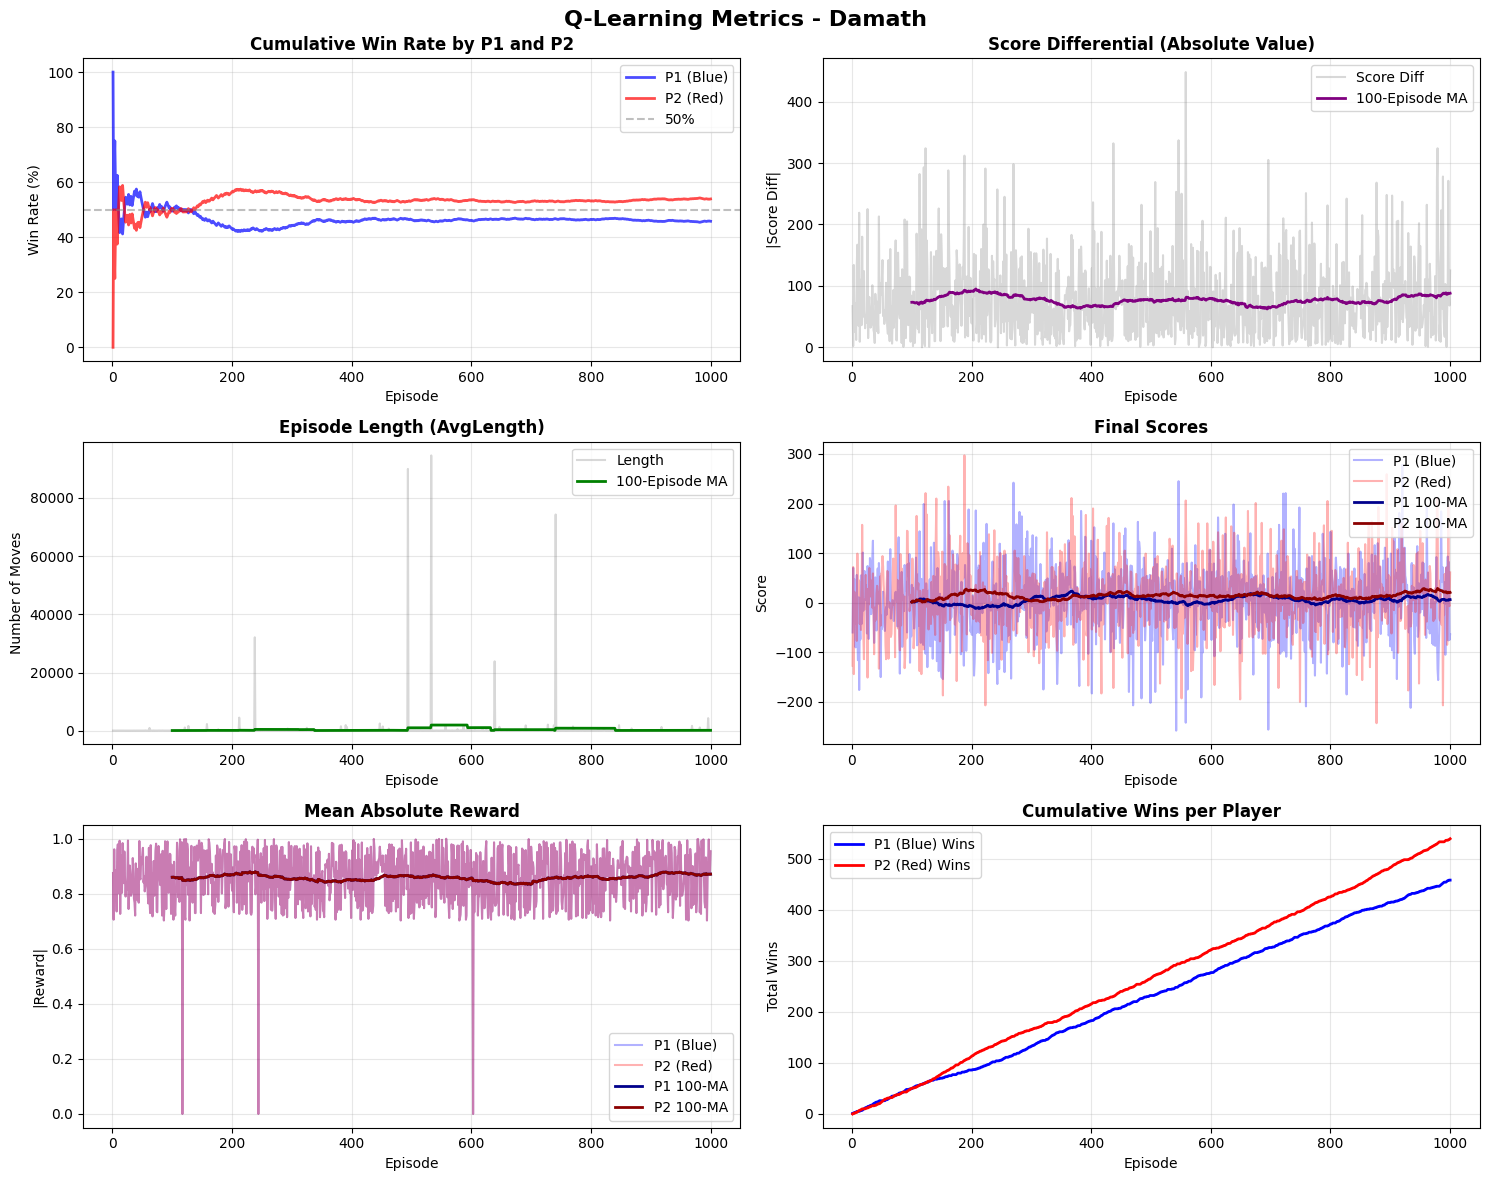

✅ Metrics saved to damath_training_metrics.csv

EVALUATING TRAINED AGENT

Evaluating agent over 1000 games...


Evaluation: 100%|██████████| 1000/1000 [02:07<00:00,  7.85it/s]



EVALUATION RESULTS:
Games Played: 1000

Cumulative Wins:
  Agent (Blue): 428 (42.8%)
  Random (Red): 567 (56.7%)
  Draws: 5

Score Metrics:
  Avg Score Differential: 75.07
  Agent Avg Score: -6.0
  Random Avg Score: 4.8
  Score Margin: -10.8

Episode Metrics:
  Avg Episode Length: 159.85

Reward Metrics:
  Agent Mean Absolute Reward: 0.8550
  Random Mean Absolute Reward: 0.8550


Generating evaluation metrics plots...


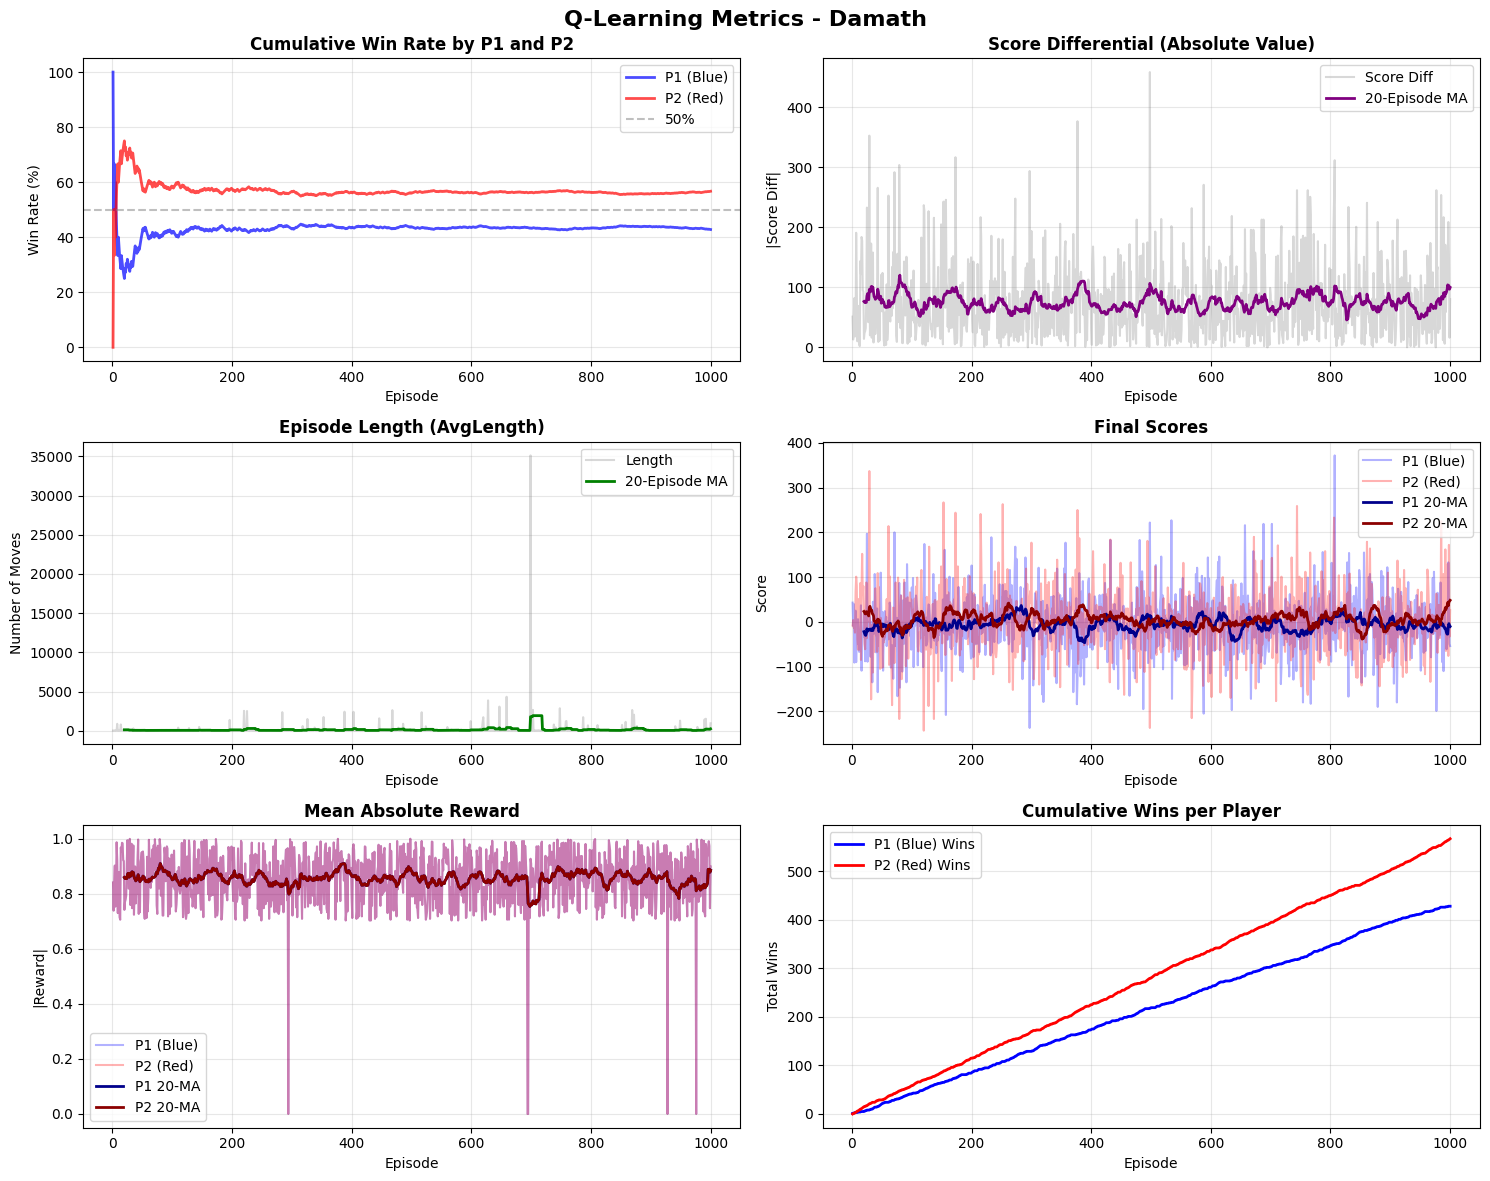


ALL METRICS AND VISUALIZATIONS COMPLETE!

Files generated:
  1. damath_training_metrics.csv
  2. damath_evaluation_metrics.csv
  3. damath_agent_trained_with_metrics.pkl
  4. Training metrics plots (displayed)
  5. Evaluation metrics plots (displayed)


In [ ]:
if __name__ == "__main__":
    print("="*60)
    print("Q-LEARNING DAMATH TRAINING WITH COMPREHENSIVE METRICS")
    print("="*60)
    print("\nStarting Q-Learning training with self-play...")
    print("Agent plays as both Blue (Player 1) and Red (Player -1)\n")
    
    # Train the agent with metrics tracking
    trained_agent, training_metrics = train_qlearning_selfplay_with_metrics(
        episodes=1000,
        reward_alpha=0.7,
        learning_rate=0.01,
        gamma=0.5,
        epsilon=0.2,
        K=100.0
    )
    
    print("\n" + "="*60)
    print("TRAINING COMPLETED!")
    print("="*60)
    
    # Print comprehensive training summary
    training_metrics.print_summary()
    
    # Plot training metrics
    print("\nGenerating training metrics plots...")
    training_metrics.plot_metrics(window=100)
    
    # Save training metrics to CSV
    training_metrics.save_to_csv('damath_training_metrics.csv')
    
    # Save trained agent Q-table
    trained_agent.save('damath_agent_trained_with_metrics.pkl')
    print("✅ Agent Q-table saved to 'damath_agent_trained_with_metrics.pkl'\n")
    
    # Evaluate the trained agent with metrics
    print("\n" + "="*60)
    print("EVALUATING TRAINED AGENT")
    print("="*60)
    
    eval_metrics = evaluate_agent_with_metrics(
        trained_agent, 
        num_games=1000,
        reward_alpha=0.7,
        K=100.0
    )
    
    # Save evaluation metrics to CSV
    eval_metrics.save_to_csv('damath_evaluation_metrics.csv')
    
    print("\n" + "="*60)
    print("ALL METRICS AND VISUALIZATIONS COMPLETE!") 
    print("="*60)
    print("\nFiles generated:")
    print("  1. damath_training_metrics.csv")
    print("  2. damath_evaluation_metrics.csv")
    print("  3. damath_agent_trained_with_metrics.pkl")
    print("  4. Training metrics plots (displayed)")



    print("="*60)    print("  5. Evaluation metrics plots (displayed)")    print("  4. Training metrics plots (displayed)")
    print("  5. Evaluation metrics plots (displayed)")
    print("="*60)


In [9]:
# Save evaluation metrics to CSV
eval_metrics.save_to_csv('damath_low-gamma_evaluation.csv')
    
# Save trained agent
trained_agent.save('damath_agent_low-gamma.pkl')
print("✅ Agent saved to damath_agent_low-gamma.pkl")

✅ Metrics saved to damath_low-gamma_evaluation.csv
✅ Agent saved to damath_agent_low-gamma.pkl
